Name:Premanshu Devendra Kusre  
Roll No: CS23117  
Subject: Machine Learning  
Topic: Network Anomaly Detection  
Dataset: UNSW-NB15  
Model Used: Logistic Regression

AIM

To implement the Logistic Regression algorithm on the UNSW-NB15 dataset
for detecting network anomalies and classifying network traffic.

DATASET DESCRIPTION

The UNSW-NB15 dataset contains network traffic data with both normal and malicious activities. It includes multiple features such as protocol, service, and statistical attributes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/ML Dataset/UNSW_NB15_training-set.csv")

In [4]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [5]:
df.shape

(82332, 45)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [7]:
df['label'].value_counts()

,count
label,
1,45332
0,37000


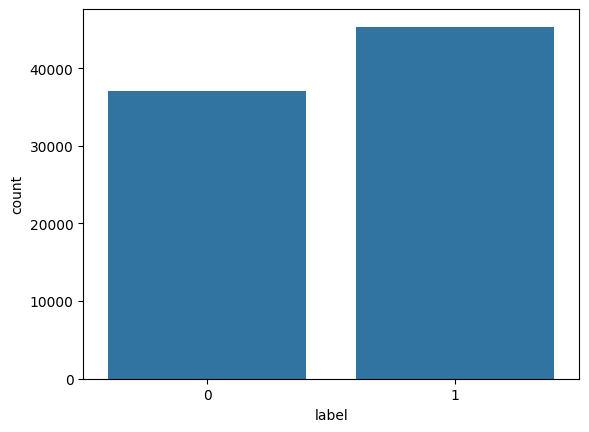

In [8]:
sns.countplot(x='label', data=df)
plt.show()

In [9]:
encoder = LabelEncoder()

df['proto'] = encoder.fit_transform(df['proto'])
df['service'] = encoder.fit_transform(df['service'])
df['state'] = encoder.fit_transform(df['state'])

In [10]:
df = df.drop(['attack_cat'], axis=1)

In [11]:
X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [12]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (57632, 43)
Testing shape: (24700, 43)


FEATURE SCALING

Feature scaling is applied because Logistic Regression performs better
when all features are on a similar scale. StandardScaler is used to normalize the data.

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

MODEL IMPLEMENTATION

Logistic Regression is used for binary classification.
It models the probability of a class using a sigmoid function.

In [14]:
lr_model = LogisticRegression(max_iter=2000, random_state=42)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000, random_state=42)

In [15]:
y_pred = lr_model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy: {:.2f}%".format(accuracy * 100))

Logistic Regression Accuracy: 95.02%


In [17]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10526   621]
 [  609 12944]]


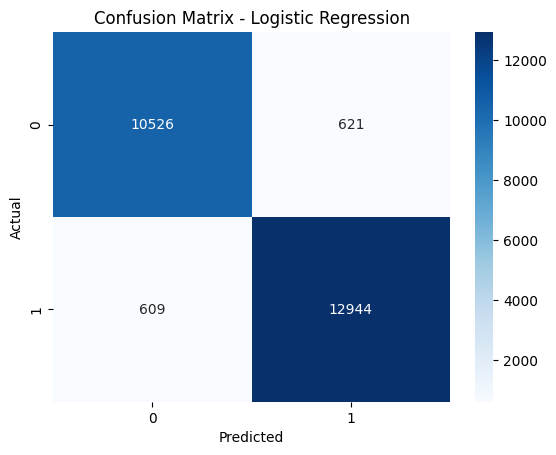

In [18]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94     11147
           1       0.95      0.96      0.95     13553

    accuracy                           0.95     24700
   macro avg       0.95      0.95      0.95     24700
weighted avg       0.95      0.95      0.95     24700



RESULT

The Logistic Regression model was successfully implemented on the
UNSW-NB15 dataset.

Feature scaling was applied to improve model performance.
The model performed well for binary classification, but its performance
is lower compared to Random Forest due to its linear nature.

Logistic Regression is simple and efficient but may not capture complex patterns.